# Libraries

In [750]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [751]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240426 - Ag60 GDE_0.6 M Na2SO4_pH3

14-Aug-26  06:29 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
06-Jun-26  11:04 PM    <DIR>          .ipynb_checkpoints
29-Apr-24  10:20 AM           113,821 0p6M_pH3 Na2SO4_20240429_0819_1min - Copy.xlsx
03-Aug-26  11:38 AM            83,291 0p6M_pH3 Na2SO4_20240429_0819_1min.xlsx
29-Apr-24  10:20 AM           409,011 0p6M_pH3 Na2SO4_20240429_0819_Line_1.csv
19-Jul-25  07:42 PM           824,064 20240426 - Ag60 GDE_0.6 M Na2SO4_pH3.ipynb
14-Aug-26  06:28 AM           951,479 20240426 - Ag60 GDE_0.6 M Na2SO4_pH3_CORRECTED.ipynb
11-Aug-26  08:33 AM               552 20240426_0.6 M Na2SO4_pH3_Energy Consumption.csv
11-Aug-26  05:25 PM             5,838 20240426_0.6M Na2SO4_pH3.csv
11-Aug-26  08:33 AM             1,406 20240426_0.6M Na2SO4_pH3_flow rate.csv
07-Jun-26  03:15 PM           135,023 

# Load Data

In [752]:
Book = "Book_20240426 - Ag60 GDE_0.6 M Na2SO4_pH3.xlsx"
Book = pd.read_excel(Book)
Book.tail(10)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
109,Ag60 GDE in PTFE holder,60,7.150870,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 04:35:00,62.550000,31.013268,...,0.301461,0.222024,0.469312,0.002790,0.570627,0.420264,NaN,0.990890,0.321153,102.135615
110,Ag60 GDE in PTFE holder,60,7.030791,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 05:11:00,63.150000,31.116415,...,0.302281,0.221628,0.468957,0.002774,0.562571,0.412468,NaN,0.975040,0.320928,NaN
111,Ag60 GDE in PTFE holder,60,6.675440,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 05:47:00,63.750000,31.125123,...,0.302572,0.221247,0.469171,0.002743,0.534652,0.390949,NaN,0.925601,0.320454,102.147365
112,Ag60 GDE in PTFE holder,60,6.830873,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 06:23:00,64.350000,31.288043,...,0.302558,0.221449,0.468815,0.002788,0.547075,0.400416,NaN,0.947491,0.320817,NaN
113,Ag60 GDE in PTFE holder,60,6.967895,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 07:00:00,64.966667,31.431581,...,0.303499,0.222321,0.466944,0.002774,0.559784,0.410056,NaN,0.969841,0.322548,102.814615
114,Ag60 GDE in PTFE holder,60,6.940771,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 07:36:00,65.566667,31.649371,...,0.306001,0.223501,0.463251,0.002755,0.562202,0.410629,NaN,0.972832,0.325446,NaN
115,Ag60 GDE in PTFE holder,60,6.909617,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 08:12:00,66.166667,31.797280,...,0.307175,0.224602,0.461028,0.002732,0.561827,0.410800,NaN,0.972627,0.327585,102.770291
116,Ag60 GDE in PTFE holder,60,6.852599,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 08:48:00,66.766667,31.967478,...,0.308469,0.224826,0.459579,0.002715,0.559538,0.407815,NaN,0.967353,0.328498,NaN
117,Ag60 GDE in PTFE holder,60,7.192136,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 09:24:00,67.366667,31.769662,...,0.307292,0.223623,0.462141,0.002692,0.585021,0.425731,NaN,1.010753,0.326093,102.667886
118,Ag60 GDE in PTFE holder,60,6.786569,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 10:00:00,67.966667,31.746045,...,0.308505,0.223402,0.468093,0.001224,0.554210,0.401329,NaN,0.955539,0.323072,NaN


In [753]:
# NOTE: do NOT rescale the Excel FE columns here.
# The old "FE * 100" line caused totals > 300% whenever this cell was
# re-run, and we recompute FE from scratch further down anyway.
Book.head(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,56.151374,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-04-26 14:02:00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN
1,Ag60 GDE in PTFE holder,60,55.082611,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:11:00,0.150000,0.122692,...,0.001205,0.008632,0.987145,0.000937,0.070833,0.507508,NaN,0.578341,0.008669,101.529106
2,Ag60 GDE in PTFE holder,60,57.183324,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:36:00,0.566667,0.166520,...,0.001639,0.014732,0.981426,0.000698,0.100008,0.899179,NaN,0.999186,0.014789,NaN


In [754]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
116,Ag60 GDE in PTFE holder,60,6.85,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 08:48:00,66.77,31.967478,...,0.224826,0.459579,0.002715,0.559538,0.407815,NaN,0.967353,0.328498,NaN,6.85
117,Ag60 GDE in PTFE holder,60,7.19,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 09:24:00,67.37,31.769662,...,0.223623,0.462141,0.002692,0.585021,0.425731,NaN,1.010753,0.326093,102.667886,7.19
118,Ag60 GDE in PTFE holder,60,6.79,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.5,2024-04-29 10:00:00,67.97,31.746045,...,0.223402,0.468093,0.001224,0.554210,0.401329,NaN,0.955539,0.323072,NaN,6.79


### Temp from pH meter

In [755]:
Temp = "2024-04-29_102528.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 23.7575143129771
Temp C median: 23.8


## Power Supply

In [756]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.tail(5)

,U set,U ctul,I set,I ctul,P set,P ctul,R set,R ctul,R mode,Output/Input,Deice mode,Error,Time
49225,40,4.88,0.5,0.511,320.00W,2.49W,N/,N/,N/,On,CC,NaN,29/04/2024 10:25:24.342
49226,40,4.93,0.5,0.512,320.00W,2.53W,N/,N/,N/,On,CC,NaN,29/04/2024 10:25:29.342
49227,40,4.90,0.5,0.511,320.00W,2.50W,N/,N/,N/,On,CC,NaN,29/04/2024 10:25:34.342
49228,40,4.92,0.5,0.511,320.00W,2.51W,N/,N/,N/,On,CC,NaN,29/04/2024 10:25:39.342
49229,40,4.91,0.5,0.511,320.00W,2.51W,N/,N/,N/,On,CC,NaN,29/04/2024 10:25:43.279


In [757]:
power_sup.groupby("I set", group_keys=True)[['U ctul']].apply(lambda x: x).head(3)

U ctul
I set              
0.0   0        0.00
      40649    2.20
0.1   1        3.63

In [758]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d/%m/%Y %H:%M:%S.%f"
)

# power_sup["I ctul"] = (
#     power_sup["I ctul"]
#     .str.replace("A", "", regex=False)
#     .str.strip()
#     .astype(float)
# )
# power_sup["U ctul"] = (
#     power_sup["U ctul"]
#     .str.replace("V", "", regex=False)
#     .str.strip()
#     .astype(float)
# )

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I ctul": "max",
        "U ctul": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                  Time  I ctul  U ctul
0  2024-04-26 14:00:00   0.124    3.67
1  2024-04-26 16:00:00   0.273    4.60
2  2024-04-26 18:00:00   0.520    5.67
3  2024-04-26 20:00:00   0.771    6.31
4  2024-04-26 22:00:00   1.018    6.83
5  2024-04-27 00:00:00   1.516    8.07
6  2024-04-27 02:00:00   2.021    9.03
7  2024-04-27 04:00:00   3.016   10.94
8  2024-04-27 06:00:00   3.009   10.15
9  2024-04-27 08:00:00   0.518    5.28
10 2024-04-27 10:00:00   0.520    5.23
11 2024-04-27 12:00:00   0.518    5.17
12 2024-04-27 14:00:00   0.520    5.21
13 2024-04-27 16:00:00   0.518    5.22
14 2024-04-27 18:00:00   0.520    5.22
15 2024-04-27 20:00:00   0.519    5.24
16 2024-04-27 22:00:00   0.520    5.22
17 2024-04-28 00:00:00   0.518    5.17
18 2024-04-28 02:00:00   0.519    5.15
19 2024-04-28 04:00:00   0.517    5.18
20 2024-04-28 06:00:00   0.517    5.14
21 2024-04-28 08:00:00   0.521    5.10
22 2024-04-28 10:00:00   0.520    5.13
23 2024-04-28 12:00:00   0.517    5.13
24 2024-04-28 14:00:00   

In [759]:
# cell_voltage = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-27].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I ctul  U ctul
0 2024-04-26 14:00:00   0.124    3.67
1 2024-04-26 16:00:00   0.273    4.60
2 2024-04-26 18:00:00   0.520    5.67
3 2024-04-26 20:00:00   0.771    6.31
4 2024-04-26 22:00:00   1.018    6.83
5 2024-04-27 00:00:00   1.516    8.07
6 2024-04-27 02:00:00   2.021    9.03
7 2024-04-27 04:00:00   3.016   10.94


In [760]:
# power_sup["U ctul"] = power_sup["U ctul"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U ctul"].mean()
# cell_voltage

In [761]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U ctul": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I ctul")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I ctul,
0.124,3.67
0.273,4.60
0.520,5.67
0.771,6.31
1.018,6.83
1.516,8.07
2.021,9.03
3.016,10.94


In [762]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I ctul,,
0.124,3.67,1.24
0.273,4.60,2.73
0.520,5.67,5.20
0.771,6.31,7.71
1.018,6.83,10.18
1.516,8.07,15.16
2.021,9.03,20.21
3.016,10.94,30.16


## FLow rate

In [763]:
flow_rate = "0p6M_pH3 Na2SO4_20240429_0819_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(20)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-04-29 08:19:58.426000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p6M_pH3 Na2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [764]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})
flow_rate.head(10)

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-04-26 12:02:59.971000,56.014325,28.007162
1,2024-04-26 12:04:00.019000,56.269375,28.134687
2,2024-04-26 12:04:59.981000,55.609683,27.804842
3,2024-04-26 12:06:00.029000,55.666209,27.833105
4,2024-04-26 12:06:59.990000,56.617366,28.308683
5,2024-04-26 12:08:00.038000,55.490428,27.745214
6,2024-04-26 12:09:00,55.461482,27.730741
7,2024-04-26 12:09:59.962000,55.082611,27.541306
8,2024-04-26 12:11:00.010000,55.682559,27.84128
9,2024-04-26 12:11:59.971000,56.306094,28.153047


In [765]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-04-26 12:00:00     55.082611     59.636264       57.50846   
1 2024-04-26 14:00:00     57.893973     61.110719       59.42526   
2 2024-04-26 16:00:00     58.612873     62.138755      60.348594   
3 2024-04-26 18:00:00     59.419282     62.702813      61.073849   
4 2024-04-26 20:00:00     60.562907     63.177943      61.979025   
5 2024-04-26 22:00:00     61.366095     65.742875      64.585003   
6 2024-04-27 00:00:00     63.799804     69.781712      68.159162   
7 2024-04-27 02:00:00      68.45632     78.429939      76.324215   
8 2024-04-27 04:00:00     54.711436      77.59155       58.49675   

  Flow_rate_median  
0        57.632963  
1        59.400969  
2        60.368477  
3         61.11657  
4         62.00279  
5         64.68087  
6         68.22138  
7        76.417599  
8        56.862077  


#### Dry flow correction

In [766]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.366 L/mol
p_sat = 2.9488 kPa -> x(H2O) = 2.91 % -> dry factor 0.97090


In [767]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [768]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I ctul']
dfflow_rate['Voltage'] = power_summary['U ctul']
dfflow_rate = dfflow_rate.iloc[:-1].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-04-26 12:00:00,55.082611,59.636264,57.50846,57.632963,53.479564,57.900694,55.834815,55.955694,0.124,3.67
1,2024-04-26 14:00:00,57.893973,61.110719,59.42526,59.400969,56.209108,59.332238,57.69583,57.672247,0.273,4.60
2,2024-04-26 16:00:00,58.612873,62.138755,60.348594,60.368477,56.907086,60.330356,58.592293,58.611598,0.520,5.67
3,2024-04-26 18:00:00,59.419282,62.702813,61.073849,61.11657,57.690027,60.877998,59.296441,59.337919,0.771,6.31
4,2024-04-26 20:00:00,60.562907,63.177943,61.979025,62.00279,58.800369,61.339301,60.175274,60.198348,1.018,6.83
5,2024-04-26 22:00:00,61.366095,65.742875,64.585003,64.68087,59.580182,63.829587,62.705411,62.798489,1.516,8.07
6,2024-04-27 00:00:00,63.799804,69.781712,68.159162,68.22138,61.943064,67.750883,66.175553,66.235961,2.021,9.03
7,2024-04-27 02:00:00,68.45632,78.429939,76.324215,76.417599,66.464063,76.147424,74.102983,74.193649,3.016,10.94


In [805]:
# dfflow_rate.to_csv('20240426_0.6M Na2SO4_pH3_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J <br>

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [806]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I ctul,,,,,
0.124,3.67,1.24,124.0,3276.576,0.000910
0.273,4.60,2.73,273.0,9041.760,0.002512
0.520,5.67,5.20,520.0,21228.480,0.005897


In [807]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I ctul,,,,,
0.124,3.67,1.24,124.0,3276.576,0.000910
0.273,4.60,2.73,273.0,9041.760,0.002512
0.520,5.67,5.20,520.0,21228.480,0.005897
0.771,6.31,7.71,771.0,35028.072,0.009730
1.018,6.83,10.18,1018.0,50061.168,0.013906
1.516,8.07,15.16,1516.0,88085.664,0.024468
2.021,9.03,20.21,2021.0,131397.336,0.036499
3.016,10.94,30.16,3016.0,237564.288,0.065990


In [808]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I ctul,,,,,
0.124,3.67,1.24,124.0,3276.576,0.000910
0.273,4.60,2.73,273.0,9041.760,0.002512
0.520,5.67,5.20,520.0,21228.480,0.005897
0.771,6.31,7.71,771.0,35028.072,0.009730
1.018,6.83,10.18,1018.0,50061.168,0.013906
1.516,8.07,15.16,1516.0,88085.664,0.024468
2.021,9.03,20.21,2021.0,131397.336,0.036499
3.016,10.94,30.16,3016.0,237564.288,0.065990


In [811]:
# dfcell_voltage.to_csv('20240426_0.6 M Na2SO4_pH3_Energy Consumption.csv')

## Integer Duration ("Applied Current /A" - Values optimization)

In [774]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,56.15,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-04-26 14:02:00,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,56.15,0.0
1,Ag60 GDE in PTFE holder,60,55.08,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:11:00,0.15,0.122692,...,0.987145,0.000937,0.070833,0.507508,NaN,0.578341,0.008669,101.529106,55.08,0.0
2,Ag60 GDE in PTFE holder,60,57.18,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:36:00,0.57,0.166520,...,0.981426,0.000698,0.100008,0.899179,NaN,0.999186,0.014789,NaN,57.18,0.0
3,Ag60 GDE in PTFE holder,60,58.12,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:02:00,1.00,0.177212,...,0.981628,0.000570,0.108294,0.919550,NaN,1.027844,0.014877,101.323773,58.12,1.0
4,Ag60 GDE in PTFE holder,60,58.05,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:27:00,1.42,0.183224,...,0.982200,0.000498,0.111789,0.892939,NaN,1.004728,0.014462,NaN,58.05,1.0
5,Ag60 GDE in PTFE holder,60,58.90,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:53:00,1.85,0.186013,...,0.982720,0.000428,0.115146,0.888732,NaN,1.003878,0.014180,101.431791,58.90,1.0
6,Ag60 GDE in PTFE holder,60,58.60,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-04-26 16:18:00,2.27,0.672239,...,0.966404,0.000387,0.189620,0.741907,NaN,0.931527,0.026029,NaN,58.60,2.0
7,Ag60 GDE in PTFE holder,60,58.57,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-04-26 16:44:00,2.70,0.572029,...,0.965850,0.000319,0.161595,0.794580,NaN,0.956175,0.027856,101.546469,58.57,2.0
8,Ag60 GDE in PTFE holder,60,58.31,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-04-26 17:09:00,3.12,0.587959,...,0.965580,0.000305,0.165301,0.795989,NaN,0.961290,0.028031,NaN,58.31,3.0
9,Ag60 GDE in PTFE holder,60,59.76,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-04-26 17:35:00,3.55,0.565023,...,0.966762,0.000316,0.163151,0.785476,NaN,0.948627,0.026987,101.362835,59.76,3.0


## Current Density

In [775]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,56.15,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-04-26 14:02:00,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,56.15,0.0,0.0
1,Ag60 GDE in PTFE holder,60,55.08,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:11:00,0.15,0.122692,...,0.000937,0.070833,0.507508,NaN,0.578341,0.008669,101.529106,55.08,0.0,-124.0
2,Ag60 GDE in PTFE holder,60,57.18,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:36:00,0.57,0.166520,...,0.000698,0.100008,0.899179,NaN,0.999186,0.014789,NaN,57.18,0.0,-124.0
3,Ag60 GDE in PTFE holder,60,58.12,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:02:00,1.00,0.177212,...,0.000570,0.108294,0.919550,NaN,1.027844,0.014877,101.323773,58.12,1.0,-124.0
4,Ag60 GDE in PTFE holder,60,58.05,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:27:00,1.42,0.183224,...,0.000498,0.111789,0.892939,NaN,1.004728,0.014462,NaN,58.05,1.0,-124.0
5,Ag60 GDE in PTFE holder,60,58.90,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:53:00,1.85,0.186013,...,0.000428,0.115146,0.888732,NaN,1.003878,0.014180,101.431791,58.90,1.0,-124.0
6,Ag60 GDE in PTFE holder,60,58.60,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-04-26 16:18:00,2.27,0.672239,...,0.000387,0.189620,0.741907,NaN,0.931527,0.026029,NaN,58.60,2.0,-270.0
7,Ag60 GDE in PTFE holder,60,58.57,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-04-26 16:44:00,2.70,0.572029,...,0.000319,0.161595,0.794580,NaN,0.956175,0.027856,101.546469,58.57,2.0,-270.0
8,Ag60 GDE in PTFE holder,60,58.31,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-04-26 17:09:00,3.12,0.587959,...,0.000305,0.165301,0.795989,NaN,0.961290,0.028031,NaN,58.31,3.0,-270.0
9,Ag60 GDE in PTFE holder,60,59.76,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-04-26 17:35:00,3.55,0.565023,...,0.000316,0.163151,0.785476,NaN,0.948627,0.026987,101.362835,59.76,3.0,-270.0


## FE(CO)

In [776]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [777]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.366 L/mol


In [778]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.124, 0.273, 0.52, 0.771, 1.018, 1.516, 2.021, 3.016]

In [779]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[6, 5, 4, 6, 7, 6, 5, 6]

In [780]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

                     c(H2)  c(CO)
Applied current / A              
0.124                0.002  0.014
0.273                0.006  0.028
0.520                0.008  0.052
0.771                0.009  0.075
1.018                0.029  0.089
1.516                0.057  0.108
2.021                0.100  0.107
3.016                0.186  0.097


In [781]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 98.7 / 86.5 %


In [782]:
# rows = rows.drop(rows[rows['FE(total)'] > 107].index) #Noise in the first measurements
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
0,Ag60 GDE in PTFE holder,60,56.15,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:02:00,0.00,0.000000,...,56.15,0.0,-124.0,0.000,0.124,55.834815,53.479564,57.900694,55.955694,0.000000
1,Ag60 GDE in PTFE holder,60,55.08,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:11:00,0.15,0.122692,...,55.08,0.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,58.592679
2,Ag60 GDE in PTFE holder,60,57.18,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:36:00,0.57,0.166520,...,57.18,0.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,97.510378
3,Ag60 GDE in PTFE holder,60,58.12,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:02:00,1.00,0.177212,...,58.12,1.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,98.697489
4,Ag60 GDE in PTFE holder,60,58.05,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:27:00,1.42,0.183224,...,58.05,1.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,96.594516
5,Ag60 GDE in PTFE holder,60,58.90,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:53:00,1.85,0.186013,...,58.90,1.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,95.107789
6,Ag60 GDE in PTFE holder,60,58.60,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 16:18:00,2.27,0.672239,...,58.60,2.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,90.423064
7,Ag60 GDE in PTFE holder,60,58.57,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 16:44:00,2.70,0.572029,...,58.57,2.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,92.866767
8,Ag60 GDE in PTFE holder,60,58.31,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 17:09:00,3.12,0.587959,...,58.31,3.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,93.773777
9,Ag60 GDE in PTFE holder,60,59.76,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 17:35:00,3.55,0.565023,...,59.76,3.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,90.300199


In [783]:
rows[rows["FE(CO)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)


In [784]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 1.42].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.27].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.4].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.1].index)
rows = rows.drop(rows[rows['Duration / h'] == 9.95].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.23].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
2,Ag60 GDE in PTFE holder,60,57.18,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:36:00,0.57,0.166520,...,57.18,0.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,97.510378
3,Ag60 GDE in PTFE holder,60,58.12,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:02:00,1.00,0.177212,...,58.12,1.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,98.697489
5,Ag60 GDE in PTFE holder,60,58.90,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:53:00,1.85,0.186013,...,58.90,1.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,95.107789
7,Ag60 GDE in PTFE holder,60,58.57,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 16:44:00,2.70,0.572029,...,58.57,2.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,92.866767
8,Ag60 GDE in PTFE holder,60,58.31,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 17:09:00,3.12,0.587959,...,58.31,3.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,93.773777
9,Ag60 GDE in PTFE holder,60,59.76,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 17:35:00,3.55,0.565023,...,59.76,3.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,90.300199
10,Ag60 GDE in PTFE holder,60,59.34,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 18:00:00,3.97,0.574832,...,59.34,3.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,93.390978
11,Ag60 GDE in PTFE holder,60,59.99,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-26 19:42:00,5.67,0.635188,...,59.99,5.0,-520.0,0.520,0.520,58.592293,56.907086,60.330356,58.611598,87.490038
12,Ag60 GDE in PTFE holder,60,61.29,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-26 19:17:00,5.25,0.832451,...,61.29,5.0,-520.0,0.520,0.520,58.592293,56.907086,60.330356,58.611598,90.129999
14,Ag60 GDE in PTFE holder,60,60.58,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-26 18:51:00,4.82,0.831452,...,60.58,4.0,-520.0,0.520,0.520,58.592293,56.907086,60.330356,58.611598,89.294848


### Mean FE per current density

In [785]:
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
2,Ag60 GDE in PTFE holder,60,57.18,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:36:00,0.57,0.166520,...,57.18,0.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,97.510378
3,Ag60 GDE in PTFE holder,60,58.12,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:02:00,1.00,0.177212,...,58.12,1.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,98.697489
5,Ag60 GDE in PTFE holder,60,58.90,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:53:00,1.85,0.186013,...,58.90,1.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,95.107789
7,Ag60 GDE in PTFE holder,60,58.57,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 16:44:00,2.70,0.572029,...,58.57,2.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,92.866767
8,Ag60 GDE in PTFE holder,60,58.31,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 17:09:00,3.12,0.587959,...,58.31,3.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,93.773777
9,Ag60 GDE in PTFE holder,60,59.76,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 17:35:00,3.55,0.565023,...,59.76,3.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,90.300199
10,Ag60 GDE in PTFE holder,60,59.34,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 18:00:00,3.97,0.574832,...,59.34,3.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,93.390978
11,Ag60 GDE in PTFE holder,60,59.99,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-26 19:42:00,5.67,0.635188,...,59.99,5.0,-520.0,0.520,0.520,58.592293,56.907086,60.330356,58.611598,87.490038
12,Ag60 GDE in PTFE holder,60,61.29,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-26 19:17:00,5.25,0.832451,...,61.29,5.0,-520.0,0.520,0.520,58.592293,56.907086,60.330356,58.611598,90.129999
14,Ag60 GDE in PTFE holder,60,60.58,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-26 18:51:00,4.82,0.831452,...,60.58,4.0,-520.0,0.520,0.520,58.592293,56.907086,60.330356,58.611598,89.294848


In [786]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        124   10.355816   86.749403     10.398793     87.750663   0.332448   
1        273   15.775433   76.807497     15.723118     77.405754   0.125642   
2        520   11.279208   77.692420     12.229880     77.883061   0.959213   
3        771    9.531730   75.715536      9.593795     75.887319   0.275353   
4       1018   22.209007   68.856318     22.188819     69.192644   0.130252   
5       1516   31.064770   59.123750     31.118306     59.040691   0.189890   
6       2021   41.682275   46.110163     43.392122     46.189902   2.168345   
7       3016   59.251204   31.547266     60.432085     31.482054   1.453645   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   1.285052   0.575816   2.225775  10.079254  ...   0.001739     0.001746  3   
1   0.688274   0.251283   1.376548  15.653588  ...   0.005657     0.005639  4   
2   0.321674   1.661406   0.557155  10.795343

## FE(H2)

In [787]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
print(rows["FE(H2)"])

2      9.759715
3     10.398793
5     10.908940
7     15.694659
8     16.125122
9     15.530374
10    15.751578
11     9.360806
12    12.246938
14    12.229880
16     9.554575
17     9.952436
18    10.055837
19     9.593795
20     8.502005
21    22.249527
22    22.692912
23    22.128110
24    21.946143
25    21.817676
26    22.419675
29    30.378191
30    31.246594
31    31.118306
32    31.053681
33    31.527077
34    33.290933
35    41.961700
36    43.392122
37    44.633429
38    45.133191
39    61.007987
40    59.856183
41    61.400109
42    52.300757
43    59.050277
44    61.891912
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

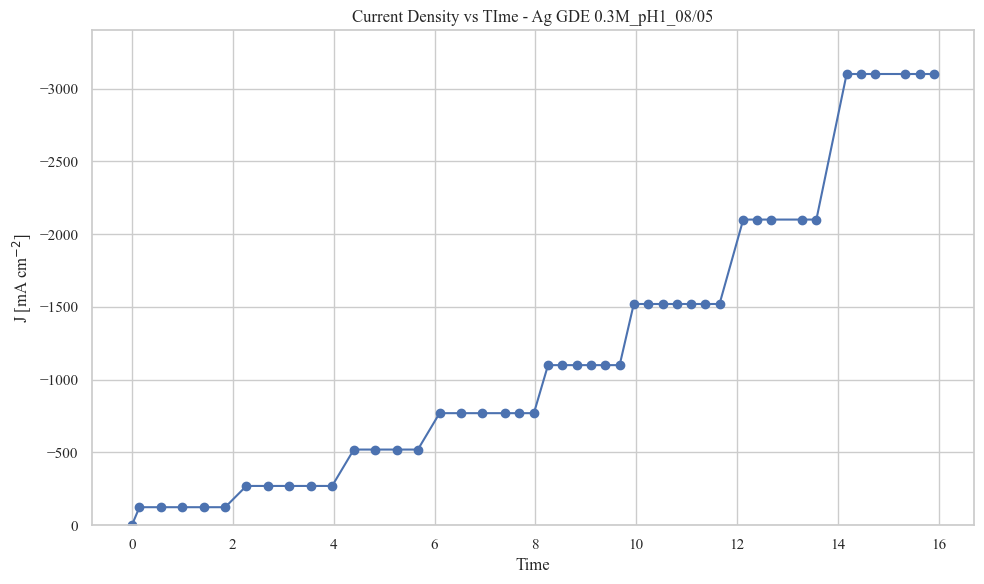

In [788]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.3M_pH1_08/05')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

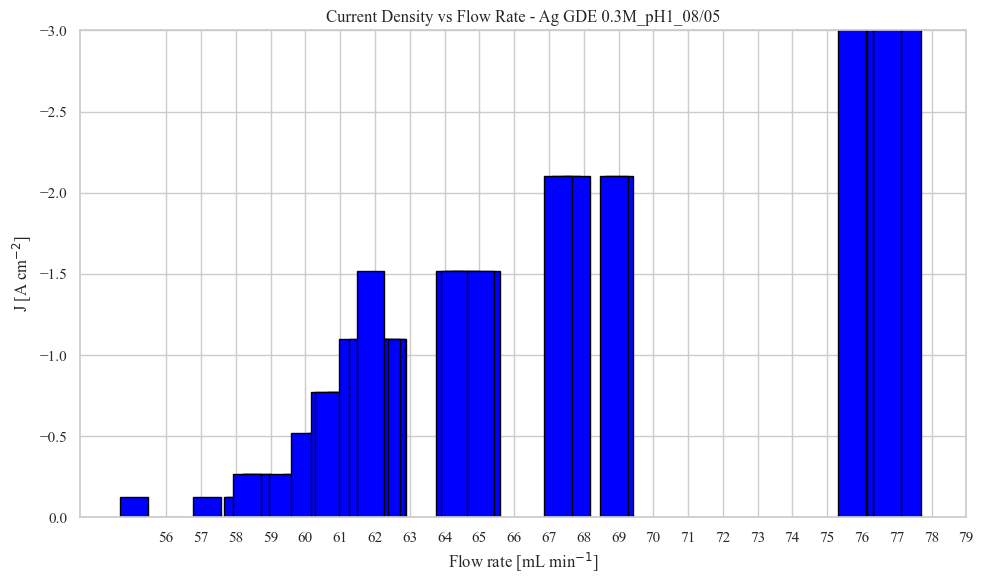

In [789]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.3M_pH1_08/05')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


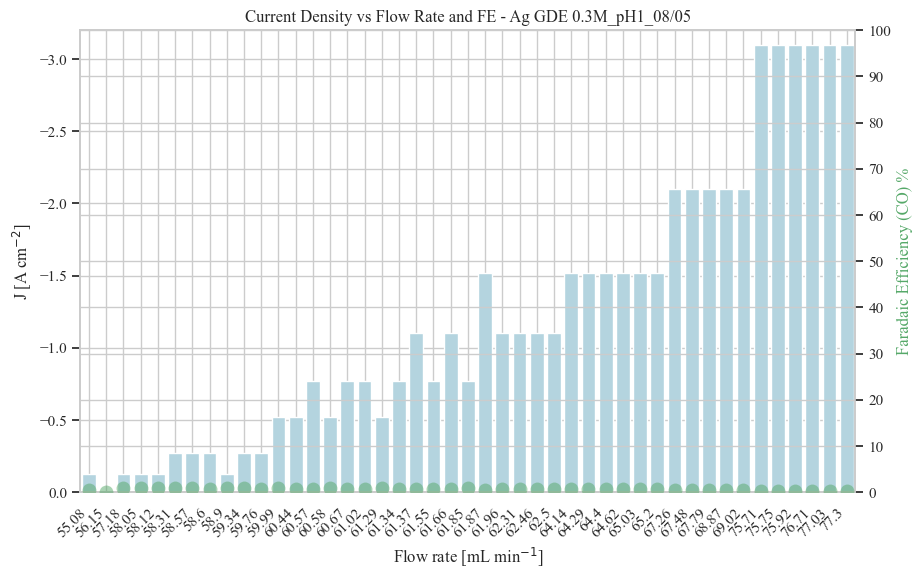

In [790]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.3M_pH1_08/05')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240508_Ag_GDE_0_3M_pH1_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [791]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [792]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240426 - Ag60 GDE_0.6 M Na2SO4_pH3

14-Aug-26  06:29 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
06-Jun-26  11:04 PM    <DIR>          .ipynb_checkpoints
29-Apr-24  10:20 AM           113,821 0p6M_pH3 Na2SO4_20240429_0819_1min - Copy.xlsx
03-Aug-26  11:38 AM            83,291 0p6M_pH3 Na2SO4_20240429_0819_1min.xlsx
29-Apr-24  10:20 AM           409,011 0p6M_pH3 Na2SO4_20240429_0819_Line_1.csv
19-Jul-25  07:42 PM           824,064 20240426 - Ag60 GDE_0.6 M Na2SO4_pH3.ipynb
14-Aug-26  06:28 AM           951,479 20240426 - Ag60 GDE_0.6 M Na2SO4_pH3_CORRECTED.ipynb
11-Aug-26  08:33 AM               552 20240426_0.6 M Na2SO4_pH3_Energy Consumption.csv
11-Aug-26  05:25 PM             5,838 20240426_0.6M Na2SO4_pH3.csv
11-Aug-26  08:33 AM             1,406 20240426_0.6M Na2SO4_pH3_flow rate.csv
07-Jun-26  03:15 PM           135,023 

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


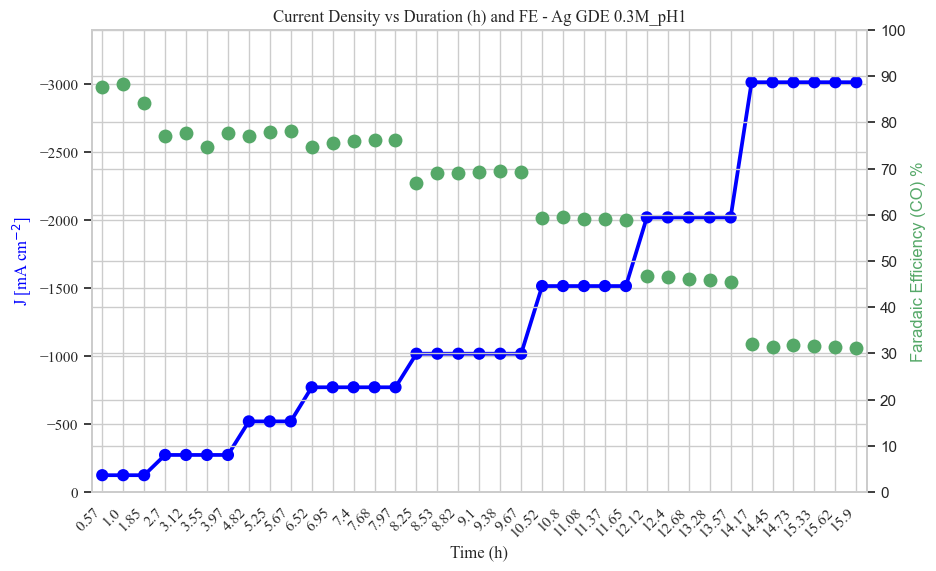

In [793]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.3M_pH1')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240508_Ag_GDE_0_3M_pH1_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Drop points from initial step of the current

In [794]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 1.42].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.27].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.4].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.1].index)
rows = rows.drop(rows[rows['Duration / h'] == 9.95].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.23].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
2,Ag60 GDE in PTFE holder,60,57.18,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 14:36:00,0.57,0.166520,...,57.18,0.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,97.510378
3,Ag60 GDE in PTFE holder,60,58.12,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:02:00,1.00,0.177212,...,58.12,1.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,98.697489
5,Ag60 GDE in PTFE holder,60,58.90,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-04-26 15:53:00,1.85,0.186013,...,58.90,1.0,-124.0,0.124,0.124,55.834815,53.479564,57.900694,55.955694,95.107789
7,Ag60 GDE in PTFE holder,60,58.57,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 16:44:00,2.70,0.572029,...,58.57,2.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,92.866767
8,Ag60 GDE in PTFE holder,60,58.31,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 17:09:00,3.12,0.587959,...,58.31,3.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,93.773777
9,Ag60 GDE in PTFE holder,60,59.76,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 17:35:00,3.55,0.565023,...,59.76,3.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,90.300199
10,Ag60 GDE in PTFE holder,60,59.34,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.273,2024-04-26 18:00:00,3.97,0.574832,...,59.34,3.0,-273.0,0.270,0.273,57.69583,56.209108,59.332238,57.672247,93.390978
11,Ag60 GDE in PTFE holder,60,59.99,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-26 19:42:00,5.67,0.635188,...,59.99,5.0,-520.0,0.520,0.520,58.592293,56.907086,60.330356,58.611598,87.490038
12,Ag60 GDE in PTFE holder,60,61.29,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-26 19:17:00,5.25,0.832451,...,61.29,5.0,-520.0,0.520,0.520,58.592293,56.907086,60.330356,58.611598,90.129999
14,Ag60 GDE in PTFE holder,60,60.58,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-26 18:51:00,4.82,0.831452,...,60.58,4.0,-520.0,0.520,0.520,58.592293,56.907086,60.330356,58.611598,89.294848


## Current Density vs FE(CO)_ mean and std

## Stacked bar plot

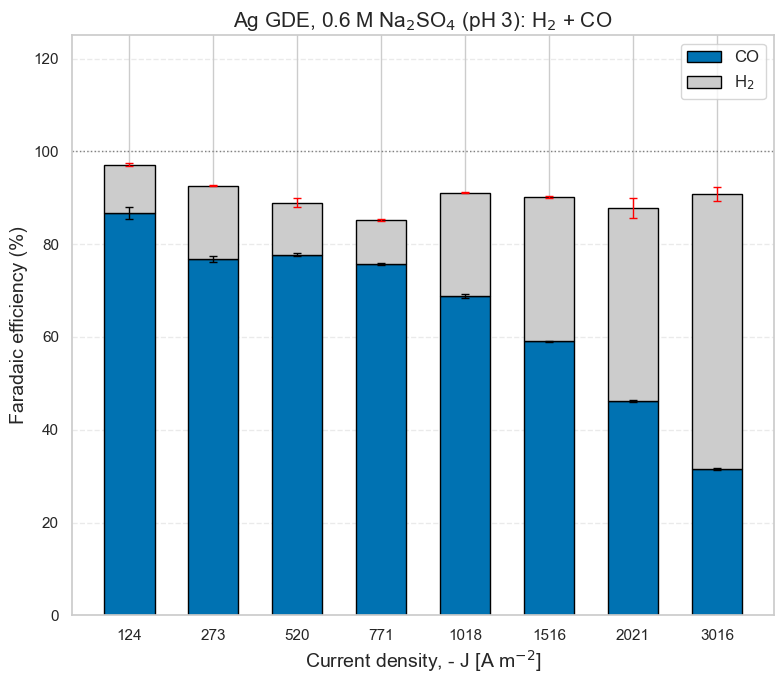

In [795]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M Na$_2$SO$_4$ (pH 3): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

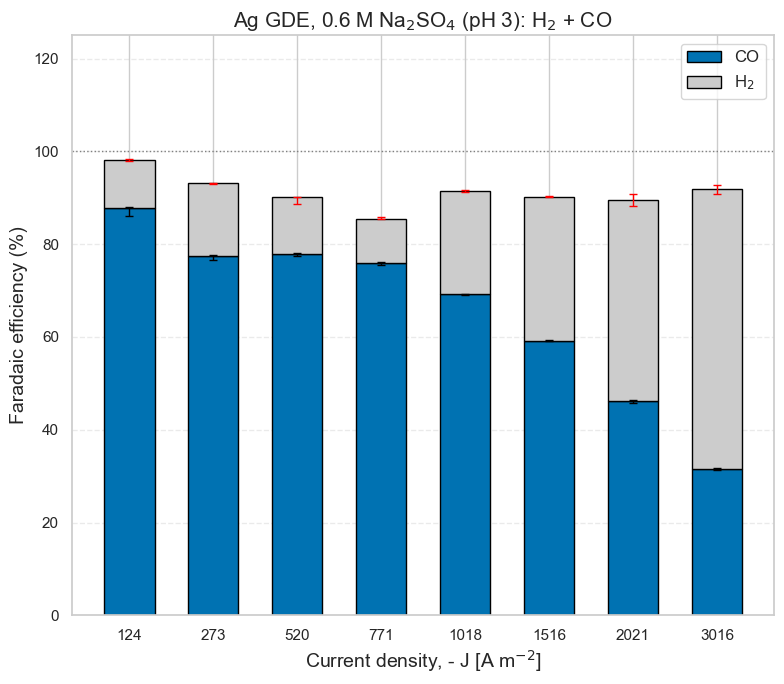

In [798]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M Na$_2$SO$_4$ (pH 3): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05)) #Automatically to 125%, but if higher it adjust (the limit of the plot)

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [799]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [800]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,10.355816,86.749403,10.398793,87.750663,0.332448,1.285052,0.575816,2.225775,10.079254,...,0.001746,3,0.319539,0.255073,1.775907,0.274016,1.201294,0.593555,0–2,124
1,250,15.775433,76.807497,15.723118,77.405754,0.125642,0.688274,0.251283,1.376548,15.653588,...,0.005639,4,0.069531,0.121845,0.834217,0.235960,0.903748,0.357805,2–4,273
2,500,11.279208,77.692420,12.229880,77.883061,0.959213,0.321674,1.661406,0.557155,10.795343,...,0.008220,3,1.434537,0.008529,0.409046,0.123085,0.902405,0.417576,4–6,520
3,750,9.531730,75.715536,9.593795,75.887319,0.275353,0.285183,0.615709,0.637688,9.554575,...,0.009444,5,0.039220,0.358641,0.279756,0.229830,0.940846,0.327734,6–8,771
4,1000,22.209007,68.856318,22.188819,69.192644,0.130252,0.394557,0.319051,0.966464,21.991635,...,0.028427,6,0.197184,0.188319,0.135040,0.143625,0.390025,0.151333,8–10,1018
5,1500,31.064770,59.123750,31.118306,59.040691,0.189890,0.107888,0.424608,0.241244,31.053681,...,0.056912,5,0.064625,0.128288,0.018434,0.265518,0.083059,0.190964,10–12,1516
6,2000,41.682275,46.110163,43.392122,46.189902,2.168345,0.230926,4.848567,0.516366,41.961700,...,0.100305,5,1.430422,1.241307,0.378751,0.305751,1.124671,0.862556,12–14,2021
7,3000,59.251204,31.547266,60.432085,31.482054,1.453645,0.135643,3.560688,0.332257,59.251754,...,0.186110,6,1.180331,0.869993,0.074706,0.200145,1.293000,0.668422,14–16,3016


In [803]:
Res_Book
# Res_Book.to_csv('20240426_0.6M Na2SO4_pH3.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,10.355816,86.749403,10.398793,87.750663,0.332448,1.285052,0.575816,2.225775,10.079254,...,0.001746,3,0.319539,0.255073,1.775907,0.274016,1.201294,0.593555,0–2,124
1,250,15.775433,76.807497,15.723118,77.405754,0.125642,0.688274,0.251283,1.376548,15.653588,...,0.005639,4,0.069531,0.121845,0.834217,0.235960,0.903748,0.357805,2–4,273
2,500,11.279208,77.692420,12.229880,77.883061,0.959213,0.321674,1.661406,0.557155,10.795343,...,0.008220,3,1.434537,0.008529,0.409046,0.123085,0.902405,0.417576,4–6,520
3,750,9.531730,75.715536,9.593795,75.887319,0.275353,0.285183,0.615709,0.637688,9.554575,...,0.009444,5,0.039220,0.358641,0.279756,0.229830,0.940846,0.327734,6–8,771
4,1000,22.209007,68.856318,22.188819,69.192644,0.130252,0.394557,0.319051,0.966464,21.991635,...,0.028427,6,0.197184,0.188319,0.135040,0.143625,0.390025,0.151333,8–10,1018
5,1500,31.064770,59.123750,31.118306,59.040691,0.189890,0.107888,0.424608,0.241244,31.053681,...,0.056912,5,0.064625,0.128288,0.018434,0.265518,0.083059,0.190964,10–12,1516
6,2000,41.682275,46.110163,43.392122,46.189902,2.168345,0.230926,4.848567,0.516366,41.961700,...,0.100305,5,1.430422,1.241307,0.378751,0.305751,1.124671,0.862556,12–14,2021
7,3000,59.251204,31.547266,60.432085,31.482054,1.453645,0.135643,3.560688,0.332257,59.251754,...,0.186110,6,1.180331,0.869993,0.074706,0.200145,1.293000,0.668422,14–16,3016


## Mean and StD of FE(CO) through time

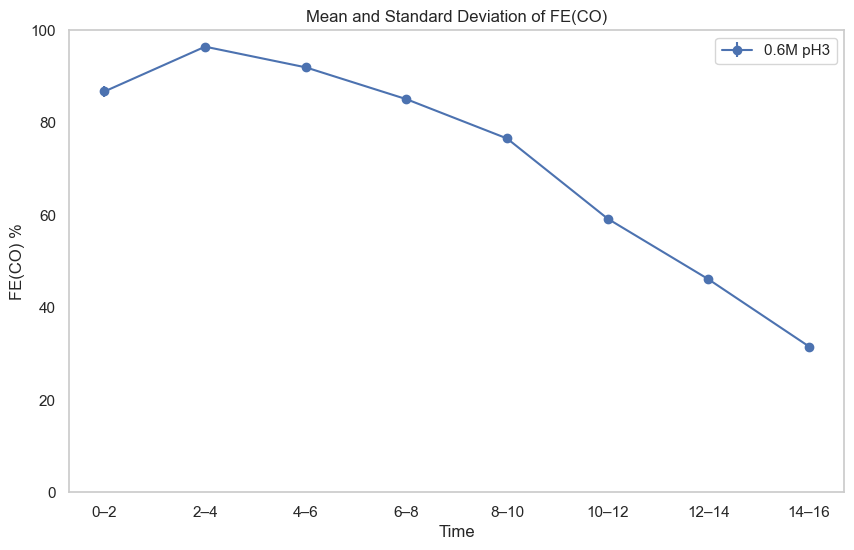

In [486]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Applied Current mean with standard deviation
# ax.errorbar(resampled_df.index, resampled_df['Applied current / A_mean'], 
#             yerr=resampled_df['Applied current / A_std'], fmt='-o', label='Applied current / A_mean')

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.6M pH3')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240508_0.3M_pH1_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

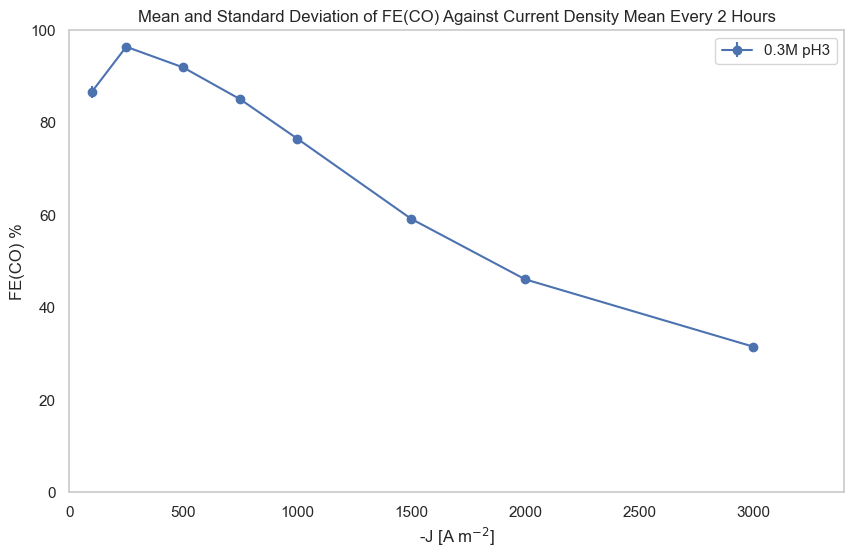

In [487]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.3M pH3')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3400)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240426_0.6M_pH3_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()

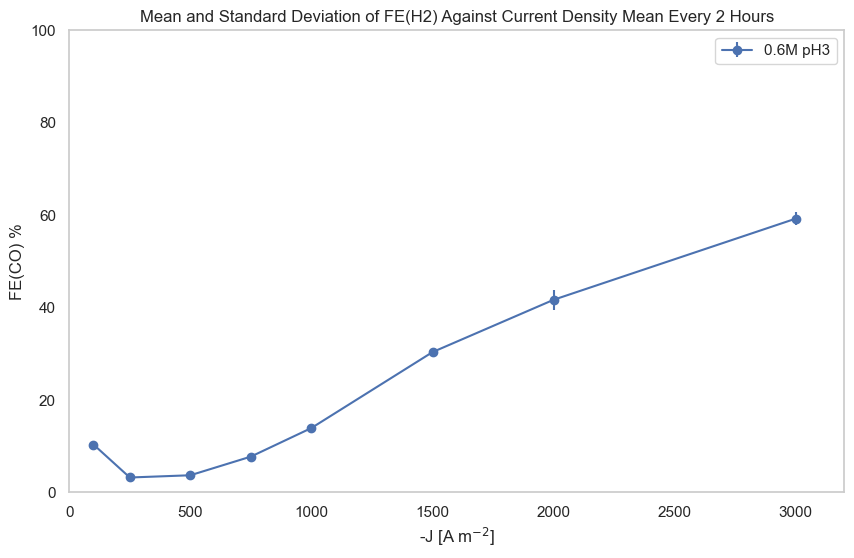

In [488]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(H2)_mean'], 
            yerr=Res_Book['FE(H2)_sem'], fmt='-o', label='0.6M pH3')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(H2) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240426_0.6M_pH3_mean_std_FE(H2)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()